In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *
from main import *

from networks.conditioning import *

import lpips


seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_args(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict


def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    args_dict['size_network'] = "large"

    ctx = TrainingContext(**args_dict, step=step, key_remap=None, seed=None, dataloaders=dataloaders, writer=False)
    if log:
        print(f"{name}: retrieved model at step {ctx.step}")

    # Disable DataParallel (needed for Hessian computation)
    # ctx.model.network = ctx.model.network.module

    # Put in eval mode and disable gradients with respect to all parameters.
    ctx.model.eval()
    for p in ctx.model.parameters():
        p.requires_grad = False

    # Normalize energies.
    # ctx.network.network.log_normalization_constant = ctx.test_perf.log_normalization_constant

    return ctx

def get_sigmas(sigma_begin, sigma_end, num_classes, device, sigma_dis):
    if sigma_dist == 'geometric':
        sigmas = torch.tensor(
            np.exp(np.linspace(np.log(sigma_begin), np.log(sigma_end),
                               num_classes))).float().to(device)
    elif sigma_dist == 'uniform':
        sigmas = torch.tensor(
            np.linspace(sigma_begin, sigma_end, num_classes)
        ).float().to(device)

    else:
        raise NotImplementedError('sigma distribution not supported')

    return sigmas

torch.set_default_dtype(torch.float32)
    # torch.set_printoptions(precision=10, sci_mode=False)

args = load_args("multigpu/all_together/energy_song_score_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2_correct", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_ImageNet_songSmall_anisoEmb_groupNorm_lambda1_mult_lr1.5e-4_lrdecay50000_1000warmup_d2", step = "best")
# args = load_args("multigpu/combined_cov_tworandvars/energy_songWavelet_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = "last")
step = "last"
ctxs = {
    # "energy-non-reg": load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda0_lr1.5e-4_lrdecay15000_1000warmup_d2", step = step),
    # "Energy-Single": load_exp("multigpu/all_together/energy_song_score_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000TRUE_1000warmup_d2_correct_truncatedDeblur_bs512", step = step),
    # "Energy-Single": load_exp("multigpu/all_together/energy_song_score_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2_correct_truncatedDeblur", step = step),
    "Energy-Dual": load_exp("multigpu/all_together/energy_song_score_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2_correct_truncatedDeblur_bs512_onlyspatial", step = step),
    # "Energy-Single": load_exp("multigpu/freq_cov/energy_songSmall_score_anisoEmb_groupNorm_lambda0_mult_lr2e-4_lrdecay50000_1000warmup_d2", step = step),
    # "Energy-Dual": load_exp("multigpu/combined_cov_tworandvars/energy_ImageNet_songSmall_anisoEmb_groupNorm_lambda1_mult_lr1.5e-4_lrdecay50000_1000warmup_d2", step = step),
    # "Denoiser": load_exp("multigpu/combined_cov_tworandvars/denoiser_ImageNet_songSmall_score_anisoEmb_groupNorm_mult_lr1.5e-4_lrdecay50000_1000warmup", step = step),
    # "energy-reg-d": load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda1_lr1.5e-4_lrdecay15000_1000warmup_d2", step = step),
    # "denoiser-anisotropic-newloss-tinbox": load_exp("test_denoiser_mult_anisotropic_newloss_newTweedie_tinbox_song_groupNorm", step = "last"),
    # "energy-anisotropic-newloss": load_exp("test_energy_mult_anisotropic_newloss_newTweedie_tinbox_song_groupNorm", step = "last"),
}

default_ctx = ctxs["Energy-Dual"]
device = default_ctx.device
dataset_info = default_ctx.dataset_info
d = dataset_info.dimension


# Load data
test_batch_size = 32
H = 32
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=args["num_workers"], seed=2
)
# 
images = next(iter(test_dataloader))  # load for testing things.

shape = (images[0].shape[0], CHW)

time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")


loss_fn_alex = lpips.LPIPS(net='alex').cuda() # best forward scores

False
multigpu/all_together/energy_song_score_anisoEmb_groupNorm_lambda1_mult_lr2e-4_lrdecay50000_1000warmup_d2_correct_truncatedDeblur_bs512_onlyspatial: retrieved model at step 25000
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth


In [80]:
step_lr = 1e-2 #0.9e-6
inp_mask_type = "half"
min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)
num_samples_coverror = 10

idx_img = 0
image_clean = images[0][idx_img:idx_img+1,:,:,:].cuda()
Sigma = torch.ones((32,32)).cuda()
training_iterations = 100
lambda_ = 0.2

for iter in range(training_iterations):

    # Compute noisy samples from clean image
    noise_levels = noise_level_sampler.sample_noise_levels(torch.Size([num_samples_coverror]), device=image_clean.device)
    denoised = torch.zeros(num_samples_coverror, *image_clean.shape[1:]).cuda()
    
    for idxs in range(num_samples_coverror):
        box_size = torch.randint(low=5, high=20, size=(1,)).item() 
        # degradation = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=noise_levels.variance[idxs], device=device, var_clean = 1e-8, inp_mask_type=inp_mask_type)]
        degradation = [SpatialCorrCovariance(matrix=Sigma.to(device=device))]
        y = image_clean + degradation[0].apply_power(torch.randn_like(image_clean).cuda(), p = 0.5)    
    
        # Compute MMSE estimator
        input = ModelInput(noisy=y, noise_level=noise_levels[idxs], covariance=degradation)
        model_output = ctxs["Energy-Dual"].model.forward(input, create_graph = False)
        denoised[idxs] = model_output.denoised[0]

    # Approximate error covariance
    residual = (image_clean - denoised).reshape(denoised.shape[0], -1)
    error_covariance = torch.einsum("bi,bj->ij", residual, residual) / residual.shape[0]
    
    # Extract the diagonal from the computed error_covariance
    error_variances_vector = torch.diag(error_covariance) # Shape: [3*H*W]
    # Reshape to an image format
    error_variances_image = error_variances_vector.reshape(3, H, W) # Shape: [3, H, W]
    # Average across the channel dimension (dim=0)
    averaged_error_variances = torch.mean(error_variances_image, dim=0) # Shape: [H, W]
    

    # Update Sigma
    Sigma = Sigma + step_lr * averaged_error_variances - step_lr * (1 - lambda_) * Sigma
    print(Sigma)

tensor([[0.9923, 0.9923, 0.9922,  ..., 0.9922, 0.9922, 0.9923],
        [0.9923, 0.9923, 0.9922,  ..., 0.9922, 0.9922, 0.9923],
        [0.9923, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9923],
        ...,
        [0.9921, 0.9921, 0.9921,  ..., 0.9921, 0.9921, 0.9921],
        [0.9921, 0.9921, 0.9921,  ..., 0.9921, 0.9921, 0.9921],
        [0.9921, 0.9921, 0.9921,  ..., 0.9921, 0.9921, 0.9921]],
       device='cuda:0')
tensor([[0.9848, 0.9847, 0.9846,  ..., 0.9844, 0.9844, 0.9845],
        [0.9847, 0.9847, 0.9845,  ..., 0.9844, 0.9844, 0.9845],
        [0.9847, 0.9847, 0.9845,  ..., 0.9843, 0.9844, 0.9846],
        ...,
        [0.9842, 0.9842, 0.9842,  ..., 0.9842, 0.9842, 0.9842],
        [0.9842, 0.9842, 0.9842,  ..., 0.9842, 0.9842, 0.9842],
        [0.9842, 0.9842, 0.9842,  ..., 0.9842, 0.9842, 0.9843]],
       device='cuda:0')
tensor([[0.9772, 0.9771, 0.9769,  ..., 0.9766, 0.9767, 0.9768],
        [0.9771, 0.9770, 0.9768,  ..., 0.9766, 0.9767, 0.9769],
        [0.9771, 0.9770, 0.9

In [ ]:


eigenvalues, eigenvectors = torch.linalg.eigh(Sigma)
sorted_eigenvalues = torch.flip(eigenvalues, dims=[0])
sorted_eigenvectors = torch.flip(eigenvectors, dims=[1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8935026..2.2567835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4787292..1.5211089].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08995008..0.41798759].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0889673..2.6538827].


Text(0.5, 1.0, 'Eigenvalues')

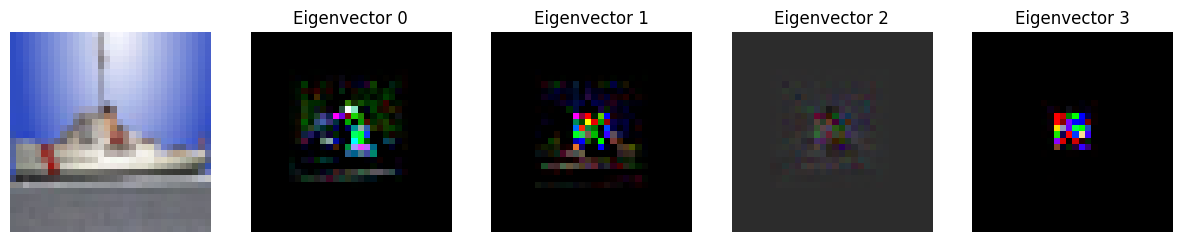

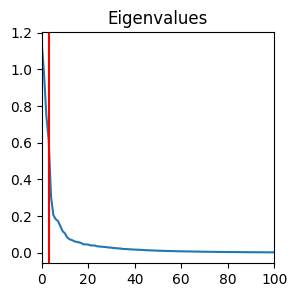

In [76]:
fig, ax = plt.subplots(1, 5, figsize=(15, 15))

# Now you can access each axis using indexing
ax[0].imshow(image_clean[0].permute(1, 2, 0).cpu().numpy())
ax[0].axis("off")
for ii in range(4):
    eigenvector = sorted_eigenvectors[:, ii]
    
    # Reshape it into an image format
    # (Assuming H=32, W=32 for this example)
    H, W = 32, 32
    eigenvector_image = eigenvector.reshape(3, H, W)
    ax[ii+1].imshow(10 * eigenvector_image.permute(1, 2, 0).cpu().numpy())
    ax[ii+1].axis("off")
    ax[ii+1].set_title(f"Eigenvector {ii}")
# ax[2].imshow(y[0].permute(1, 2, 0).cpu().numpy())
plt.figure(2, figsize=(3,3))
plt.plot(sorted_eigenvalues.cpu().numpy())
plt.xlim(0, 100)
plt.axvline(x = 3, color = 'red')
plt.title("Eigenvalues")

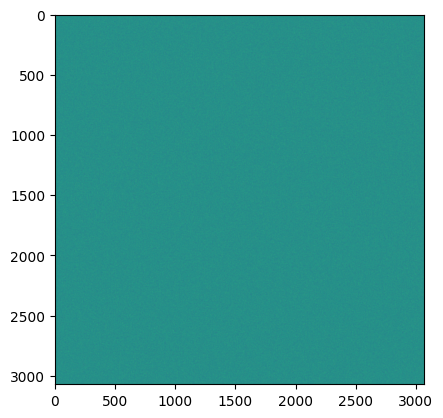

In [46]:
Sigma_old = torch.ones((3 * 32 * 32, 3 * 32 * 32)).cuda()
num_samples_coverror = 100

plt.imshow(Sigma_old.cpu().numpy())
for iter in range(training_iterations):

    # Compute noisy samples from clean image
    noise_levels = noise_level_sampler.sample_noise_levels(torch.Size([num_samples_coverror]), device=image_clean.device)
    denoised = torch.zeros(num_samples_coverror, *image_clean.shape[1:]).cuda()
    
    for idxs in range(num_samples_coverror):
        box_size = torch.randint(low=5, high=20, size=(1,)).item() 
        degradation = [spatial_corr_covariance_testing(spatial_size=H, box_size=box_size, var_box=noise_levels.variance[idxs], device=device, var_clean = 1e-8, inp_mask_type=inp_mask_type)]
        y = image_clean + degradation[0].apply_power(torch.randn_like(image_clean).cuda(), p = 0.5)    
    
        # Compute MMSE estimator
        input = ModelInput(noisy=y, noise_level=noise_levels[idxs], covariance=degradation)
        model_output = ctxs["Energy-Dual"].model.forward(input, create_graph = False)
        denoised[idxs] = model_output.denoised[0]

    # Approximate error covariance
    residual = (image_clean - denoised).reshape(denoised.shape[0], -1)
    error_covariance = torch.einsum("bi,bj->ij", residual, residual) / residual.shape[0]
    


    # Update Sigma
    Sigma_new = error_covariance / (1 - lambda_)

    if torch.mean((Sigma_new - Sigma_old)**2) < 1e-3:
        break
    else:
        Sigma_old = Sigma_new

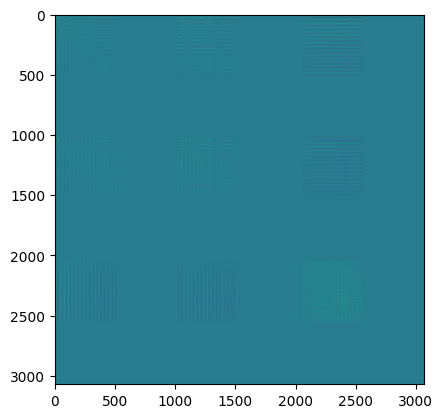

In [47]:
plt.imshow(Sigma_new.cpu().numpy())

In [ ]:
import torch

# --- Configuration ---
step_lr = 1e-1
# This parameter can be used to control which mask is generated if you don't want random selection.
# Set to "random" to alternate between "half" and "box".
inp_mask_type = "box" 
num_samples_coverror = 10
training_iterations = 100
lambda_ = 0.2

# Initialize the covariance matrix
Sigma = torch.randn((3 * H * W, 3 * H * W), device=device)

print(f"Starting covariance estimation for {training_iterations} iterations...")
for iter in range(training_iterations):
    inpainted_samples = torch.zeros(num_samples_coverror, *image_clean.shape[1:], device=device)

    # In each iteration, create a batch of different masked images
    for i in range(num_samples_coverror):
        # 1. Generate the inpainting mask (half or box)
        mask = torch.ones_like(image_clean)
        
        current_mask_type = inp_mask_type
        if current_mask_type == "box":
            box_size = torch.randint(low=5, high=20, size=(1,)).item()
            # Center the box
            start_x = (W - box_size) // 2
            start_y = (H - box_size) // 2
            mask[:, :, start_y:start_y+box_size, start_x:start_x+box_size] = 0
        elif current_mask_type == "half":
            mask[:, :, :, 0:W//2] = 0
        else:
            raise ValueError(f"Unknown mask type: {current_mask_type}")

        # 2. Apply the mask to create the corrupted image 'y'
        y = image_clean * mask

        # 3. Get the model's inpainting result
        # NOTE: The model input is now the masked image 'y', the mask itself,
        # and a small, fixed noise level. Your ModelInput class might need adjustment.
        input_data = ModelInput(noisy=y, noise_level=min_noise_level, mask=mask)
        model_output = ctxs["Energy-Dual"].model.forward(input_data, create_graph=False)
        inpainted_samples[i] = model_output.denoised[0]

    # 4. Approximate the error covariance for this batch
    # The residual is the difference between the original and the model's inpainting
    residual = (image_clean.squeeze(0) - inpainted_samples).reshape(num_samples_coverror, -1)
    # E[(x - D(y))(x - D(y))^T] is approximated by the sample covariance
    error_covariance = torch.einsum("bi,bj->ij", residual, residual) / num_samples_coverror

    # 5. Update Sigma using the derived update rule
    update = step_lr * (error_covariance - (1 - lambda_) * Sigma)
    Sigma = Sigma + update
    
    if (iter + 1) % 10 == 0:
        update_norm = torch.linalg.norm(update).item()
        print(f"Iteration [{iter+1}/{training_iterations}], Update Norm: {update_norm:.4f}")

print("\nCovariance estimation finished.")